In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("Desktop/Projects/AgriYield_AI/datasets/crop_yield.csv")
df = pd.DataFrame(data)

In [3]:
df

,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield
0,Arecanut,1997,Whole Year,Assam,73814.0,56708,2051.4,7024878.38,22882.34,0.796087
1,Arhar/Tur,1997,Kharif,Assam,6637.0,4685,2051.4,631643.29,2057.47,0.710435
2,Castor seed,1997,Kharif,Assam,796.0,22,2051.4,75755.32,246.76,0.238333
3,Coconut,1997,Whole Year,Assam,19656.0,126905000,2051.4,1870661.52,6093.36,5238.051739
4,Cotton(lint),1997,Kharif,Assam,1739.0,794,2051.4,165500.63,539.09,0.420909
...,...,...,...,...,...,...,...,...,...,...
19684,Small millets,1998,Kharif,Nagaland,4000.0,2000,1498.0,395200.00,1160.00,0.500000
19685,Wheat,1998,Rabi,Nagaland,1000.0,3000,1498.0,98800.00,290.00,3.000000
19686,Maize,1997,Kharif,Jammu and Kashmir,310883.0,440900,1356.2,29586735.11,96373.73,1.285000
19687,Rice,1997,Kharif,Jammu and Kashmir,275746.0,5488,1356.2,26242746.82,85481.26,0.016667


In [4]:
print("Shape:", df.shape)


Shape: (19689, 10)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19689 entries, 0 to 19688
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Crop             19689 non-null  object 
 1   Crop_Year        19689 non-null  int64  
 2   Season           19689 non-null  object 
 3   State            19689 non-null  object 
 4   Area             19689 non-null  float64
 5   Production       19689 non-null  int64  
 6   Annual_Rainfall  19689 non-null  float64
 7   Fertilizer       19689 non-null  float64
 8   Pesticide        19689 non-null  float64
 9   Yield            19689 non-null  float64
dtypes: float64(5), int64(2), object(3)
memory usage: 1.5+ MB


In [6]:
df.describe()

,Crop_Year,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield
count,19689.000000,1.968900e+04,1.968900e+04,19689.000000,1.968900e+04,1.968900e+04,19689.000000
mean,2009.127584,1.799266e+05,1.643594e+07,1437.755177,2.410331e+07,4.884835e+04,79.954009
std,6.498099,7.328287e+05,2.630568e+08,816.909589,9.494600e+07,2.132874e+05,878.306193
min,1997.000000,5.000000e-01,0.000000e+00,301.300000,5.417000e+01,9.000000e-02,0.000000
25%,2004.000000,1.390000e+03,1.393000e+03,940.700000,1.880146e+05,3.567000e+02,0.600000
50%,2010.000000,9.317000e+03,1.380400e+04,1247.600000,1.234957e+06,2.421900e+03,1.030000
75%,2015.000000,7.511200e+04,1.227180e+05,1643.700000,1.000385e+07,2.004170e+04,2.388889
max,2020.000000,5.080810e+07,6.326000e+09,6552.700000,4.835407e+09,1.575051e+07,21105.000000


In [7]:
df.isnull().sum()

Crop               0
Crop_Year          0
Season             0
State              0
Area               0
Production         0
Annual_Rainfall    0
Fertilizer         0
Pesticide          0
Yield              0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
numeric_cols = [
    "Area",
    "Production",
    "Annual_Rainfall",
    "Fertilizer",
    "Pesticide",
    "Yield"
]

(df[numeric_cols] < 0).sum()

Area               0
Production         0
Annual_Rainfall    0
Fertilizer         0
Pesticide          0
Yield              0
dtype: int64

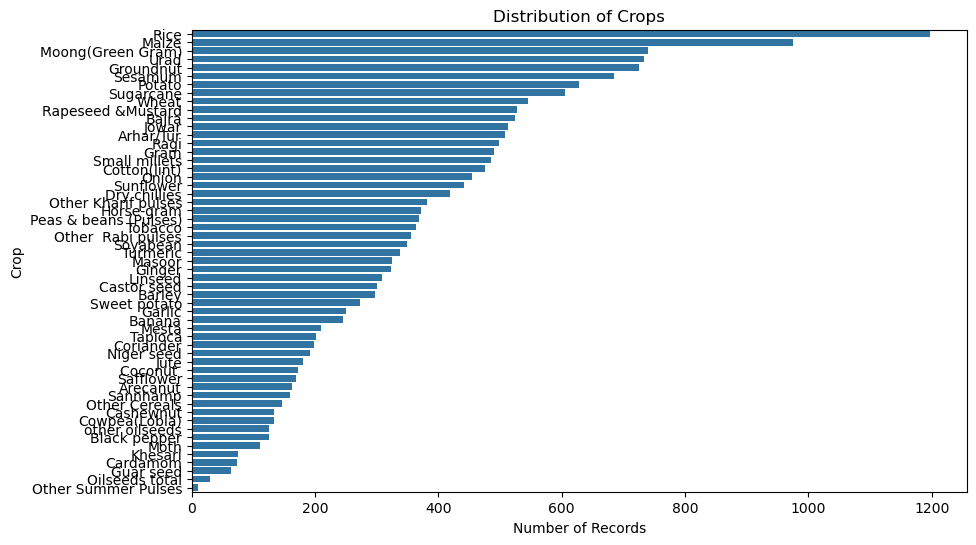

In [10]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    y="Crop",
    order=df["Crop"].value_counts().index
)

plt.title("Distribution of Crops")
plt.xlabel("Number of Records")
plt.ylabel("Crop")
plt.show()

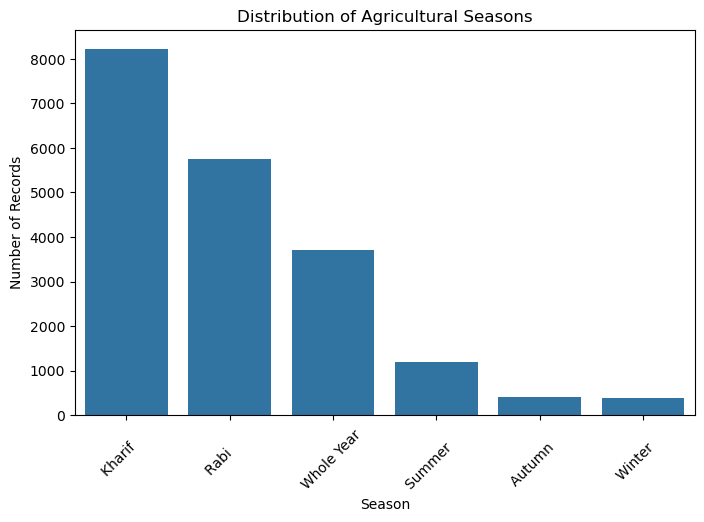

In [11]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Season",
    order=df["Season"].value_counts().index
)

plt.title("Distribution of Agricultural Seasons")
plt.xlabel("Season")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)
plt.show()

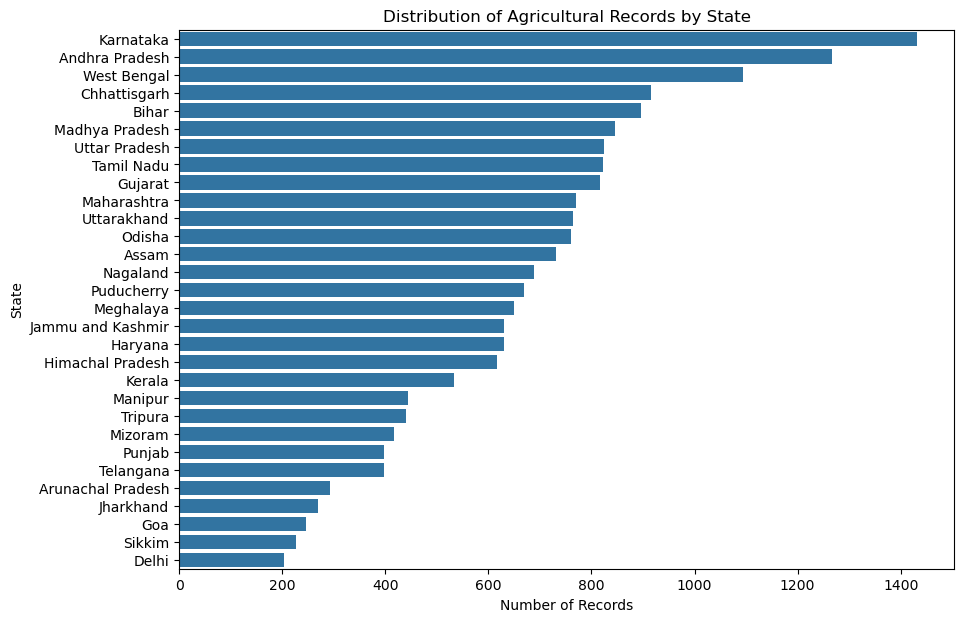

In [12]:
plt.figure(figsize=(10, 7))

sns.countplot(
    data=df,
    y="State",
    order=df["State"].value_counts().index
)

plt.title("Distribution of Agricultural Records by State")
plt.xlabel("Number of Records")
plt.ylabel("State")
plt.show()

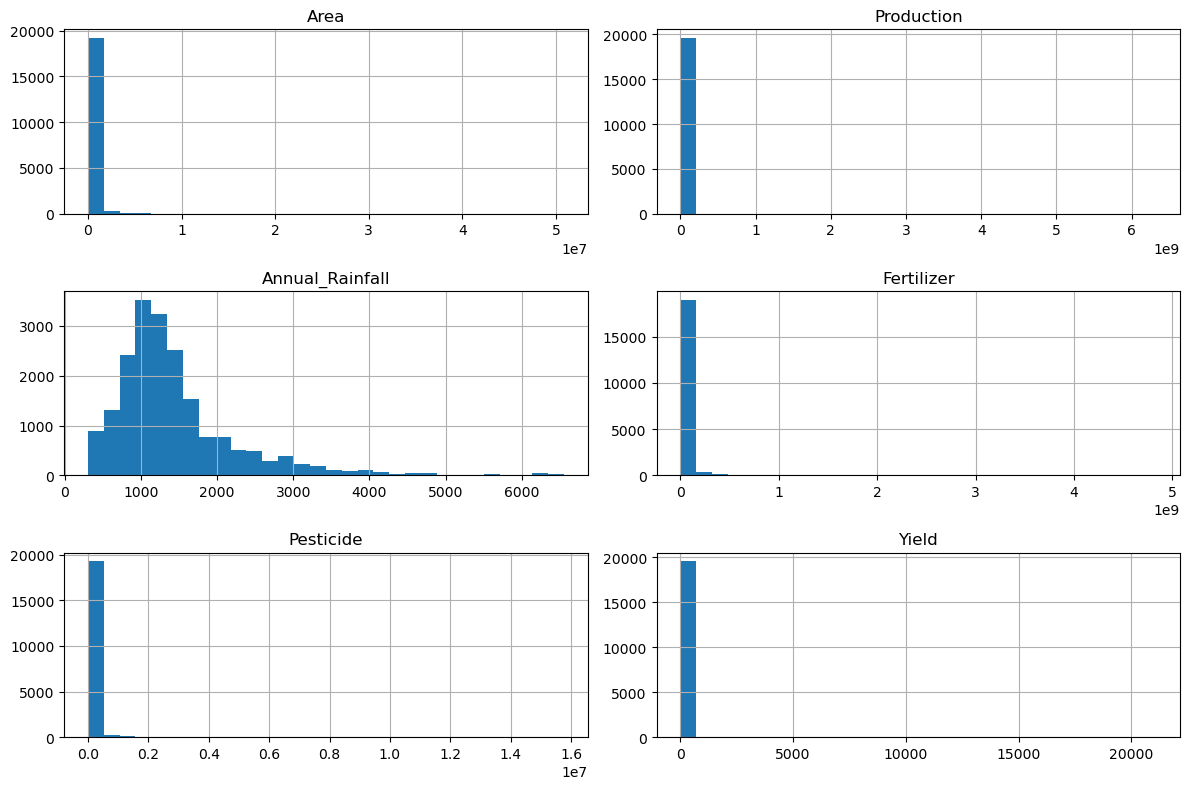

In [13]:
df[numeric_cols].hist(
    figsize=(12, 8),
    bins=30
)

plt.tight_layout()
plt.show()

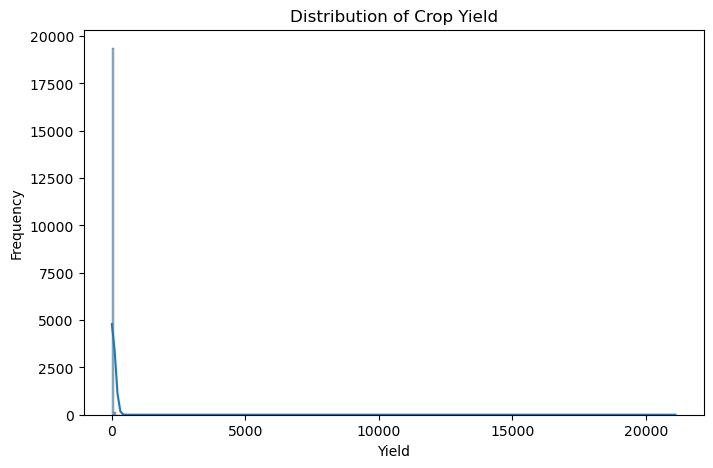

In [14]:
#Yield Analysis
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="Yield", kde=True)

plt.title("Distribution of Crop Yield")
plt.xlabel("Yield")
plt.ylabel("Frequency")
plt.show()

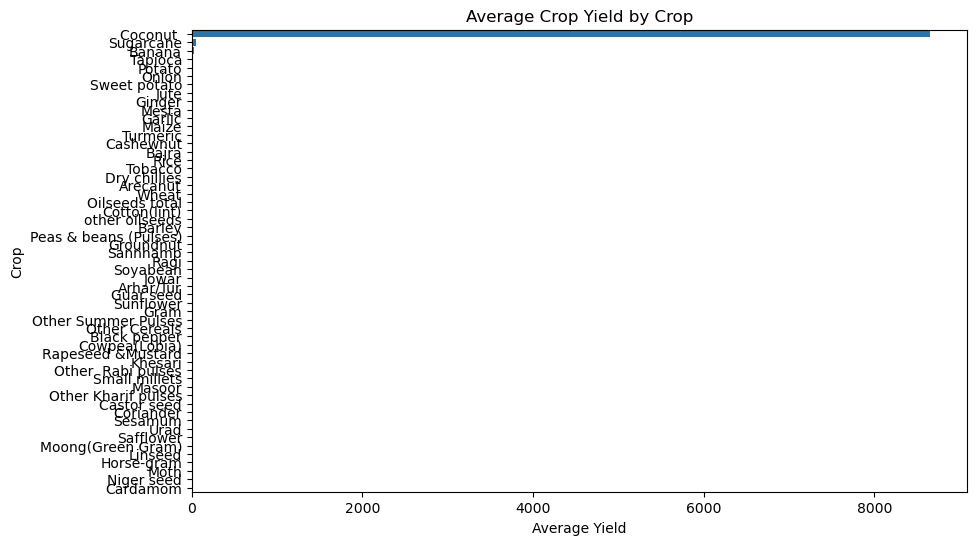

In [15]:
crop_yield = (
    df.groupby("Crop")["Yield"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=crop_yield.values,
    y=crop_yield.index
)

plt.title("Average Crop Yield by Crop")
plt.xlabel("Average Yield")
plt.ylabel("Crop")
plt.show()

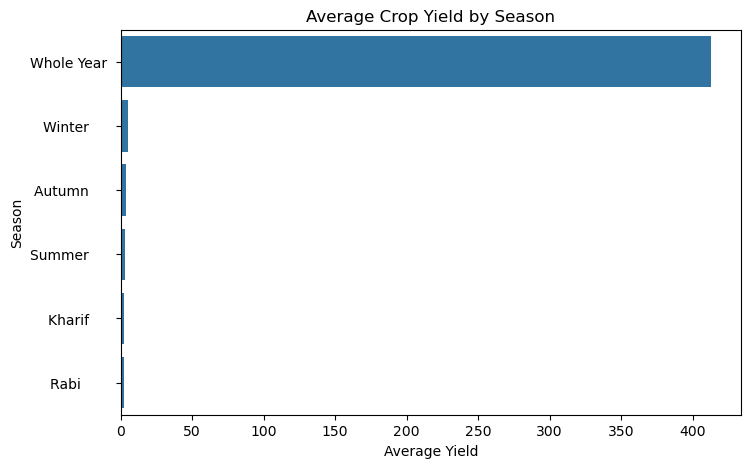

In [16]:
season_yield = (
    df.groupby("Season")["Yield"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=season_yield.values,
    y=season_yield.index
)

plt.title("Average Crop Yield by Season")
plt.xlabel("Average Yield")
plt.ylabel("Season")
plt.show()

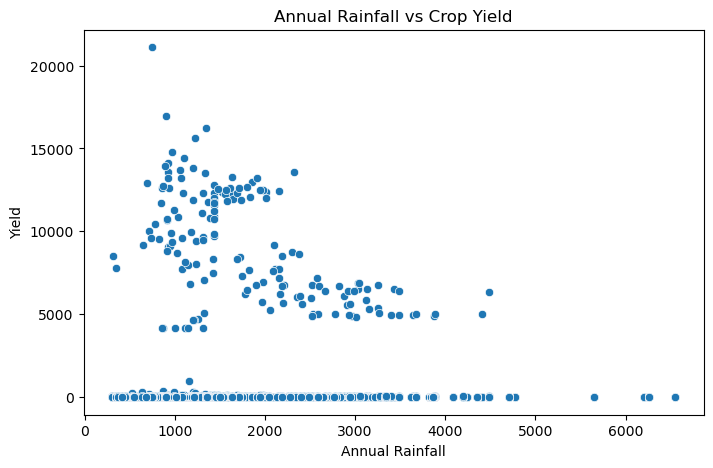

In [17]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Annual_Rainfall",
    y="Yield"
)

plt.title("Annual Rainfall vs Crop Yield")
plt.xlabel("Annual Rainfall")
plt.ylabel("Yield")
plt.show()

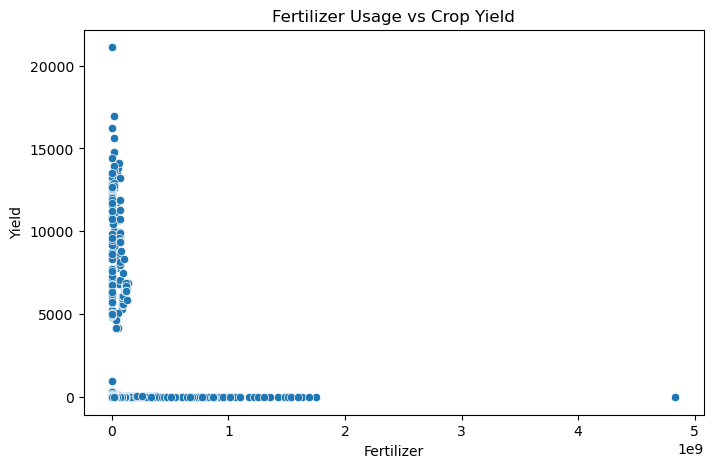

In [18]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Fertilizer",
    y="Yield"
)

plt.title("Fertilizer Usage vs Crop Yield")
plt.xlabel("Fertilizer")
plt.ylabel("Yield")
plt.show()

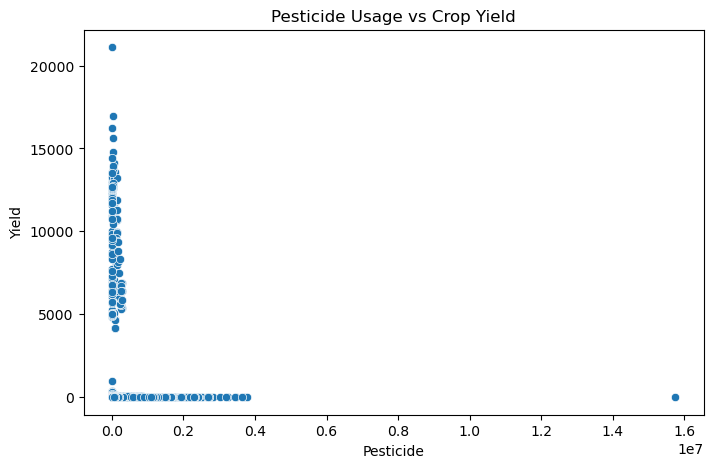

In [19]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Pesticide",
    y="Yield"
)

plt.title("Pesticide Usage vs Crop Yield")
plt.xlabel("Pesticide")
plt.ylabel("Yield")
plt.show()

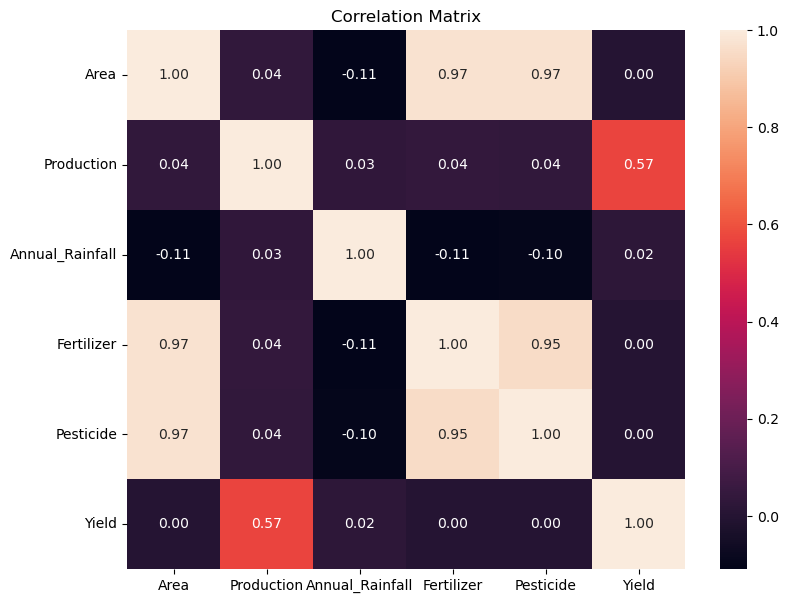

In [20]:
corr = df[numeric_cols].corr()

plt.figure(figsize=(9, 7))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

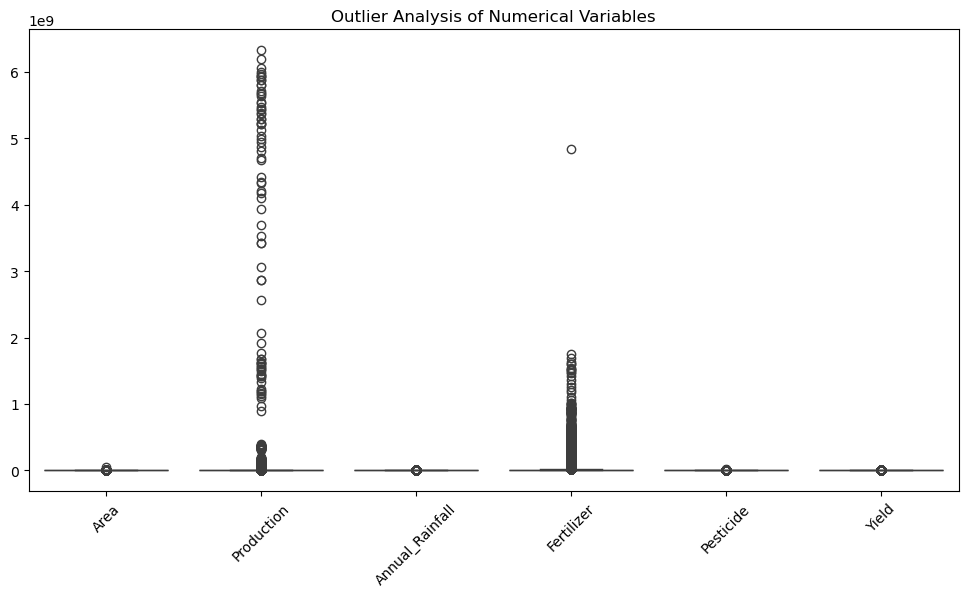

In [21]:
plt.figure(figsize=(12, 6))

sns.boxplot(data=df[numeric_cols])

plt.title("Outlier Analysis of Numerical Variables")
plt.xticks(rotation=45)
plt.show()

In [22]:
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = ((df[col] < lower) | (df[col] > upper)).sum()

    print(f"{col}: {count} potential outliers")

Area: 3076 potential outliers
Production: 3373 potential outliers
Annual_Rainfall: 1527 potential outliers
Fertilizer: 3093 potential outliers
Pesticide: 3036 potential outliers
Yield: 3065 potential outliers


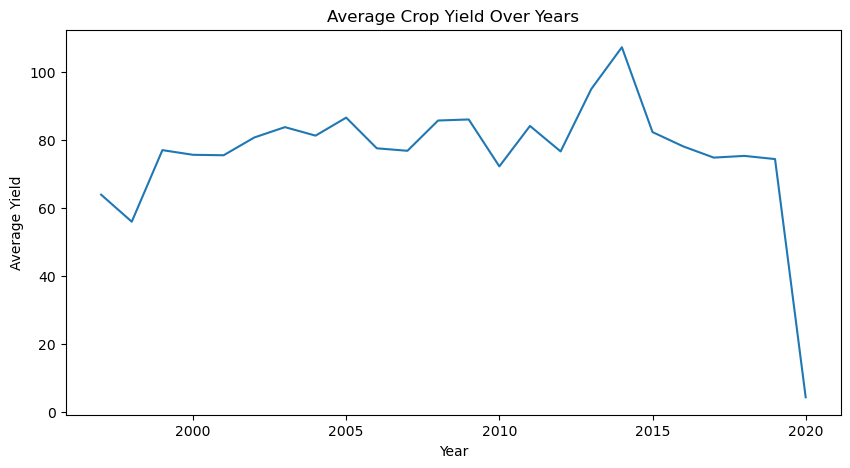

In [23]:
yearly_yield = df.groupby("Crop_Year")["Yield"].mean()

plt.figure(figsize=(10, 5))

sns.lineplot(
    x=yearly_yield.index,
    y=yearly_yield.values
)

plt.title("Average Crop Yield Over Years")
plt.xlabel("Year")
plt.ylabel("Average Yield")
plt.show()

In [25]:
# ## EDA Findings

# - The dataset contains 19,689 agricultural records and 10 attributes.
# - The dataset contains crop, year, season, state, area, production,
#   rainfall, fertilizer, pesticide, and yield information.
# - Missing values, duplicate records, and invalid negative values were
#   checked during data-quality analysis.
# - Crop, season, and state distributions were analyzed to understand
#   the categorical structure of the dataset.
# - Numerical distributions were examined for Area, Production,
#   Annual Rainfall, Fertilizer, Pesticide, and Yield.
# - Crop yield varies across different crops and agricultural seasons.
# - The relationship between yield and important agricultural factors
#   such as rainfall, fertilizer, and pesticide usage was investigated.
# - Correlation analysis was performed to identify relationships among
#   numerical variables.
# - Potential outliers were identified using boxplots and the IQR method.
#   These will be investigated before deciding whether any should be
#   removed or transformed.
# - Historical yield trends were examined using Crop_Year.
# - Production shows a relatively strong relationship with Yield;
#   however, Production requires further investigation for possible
#   target leakage before being considered as a prediction feature.
# - The findings from this dataset will later be combined with weather
#   and soil information for the final YieldSense AI dataset.